In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
from arch.unitroot import KPSS


In [3]:
def acf1(x, nlags=None, acf_type='correlation', pacf=False, ax=None, return_values=False, **kwargs):
    """
    Calculate and optionally plot the autocorrelation or partial autocorrelation function.

    Parameters:
    - x: Input time series.
    - nlags: Number of lags to compute.
    - acf_type: 'correlation' for autocorrelation, 'covariance' for autocovariance.
    - pacf: If True, computes partial autocorrelation instead of autocorrelation.
    - ax: Matplotlib axis to plot on. If None, a new axis is created.
    - return_values: If True, the function will return the ACF/PACF values and lags.
    - **kwargs: Additional keyword arguments for the plot.

    Returns:
    - If return_values is True, returns (lags, values).
    """
    lags = np.arange(1, nlags + 1)

    if pacf:
        if acf_type == 'correlation':
            values = sm.tsa.pacf(x, nlags=nlags)[1:]
            ylabel = 'PACF'
    else:
        if acf_type == 'correlation':
            values = sm.tsa.acf(x, nlags=nlags, fft=False)[1:]
            ylabel = 'ACF'
        elif acf_type == 'covariance':
            values = sm.tsa.acovf(x, nlag=nlags)[1:]
            ylabel = 'ACoV'

    if return_values:
        return lags, values

    if ax is None:
        ax = plt.gca()

    ax.bar(lags, values, **kwargs)
    ax.axhline(0, color='black', linewidth=1)
    if acf_type == 'correlation':
        conf_level = 1.96 / np.sqrt(x.shape[0])
        ax.axhline(conf_level, color='red', linestyle='--', linewidth=1)
        ax.axhline(-conf_level, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('LAG')
    ax.set_ylabel(ylabel)

    return ax

In [4]:
# Read the dataset

X = pd.read_csv("../data/processed/tourism_long.csv",
                parse_dates=["date"])

X.head()

,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


In [32]:
X.tail()

,date,state,arrivals,overnight
6523,2025-08-01,Thüringen,436547.0,1173710.0
6524,2025-09-01,Thüringen,388441.0,966075.0
6525,2025-10-01,Thüringen,365169.0,951976.0
6526,2025-11-01,Thüringen,286528.0,703055.0
6527,2025-12-01,Thüringen,270557.0,680998.0


In [8]:
# Show all unique state names

states = X["state"].unique()

print("Number of states:", len(states))
print("States:")
print(states)

Number of states: 16
States:
['Baden-Württemberg' 'Bayern' 'Berlin' 'Brandenburg' 'Bremen' 'Hamburg'
 'Hessen' 'Mecklenburg-Vorpommern' 'Niedersachsen' 'Nordrhein-Westfalen'
 'Rheinland-Pfalz' 'Saarland' 'Sachsen' 'Sachsen-Anhalt'
 'Schleswig-Holstein' 'Thüringen']


In [480]:
# Select state

state_name = "Berlin"

In [481]:
# Create time series for selected state

X_state = X[X["state"] == state_name].set_index("date")

x_ts = pd.Series(
    X_state["arrivals"].values,
    index=X_state.index
)

# Ensure monthly frequency
x_ts = x_ts.asfreq("MS")

x_ts.head()

date
1992-01-01    186026.0
1992-02-01    199740.0
1992-03-01    264394.0
1992-04-01    273840.0
1992-05-01    326736.0
Freq: MS, dtype: float64

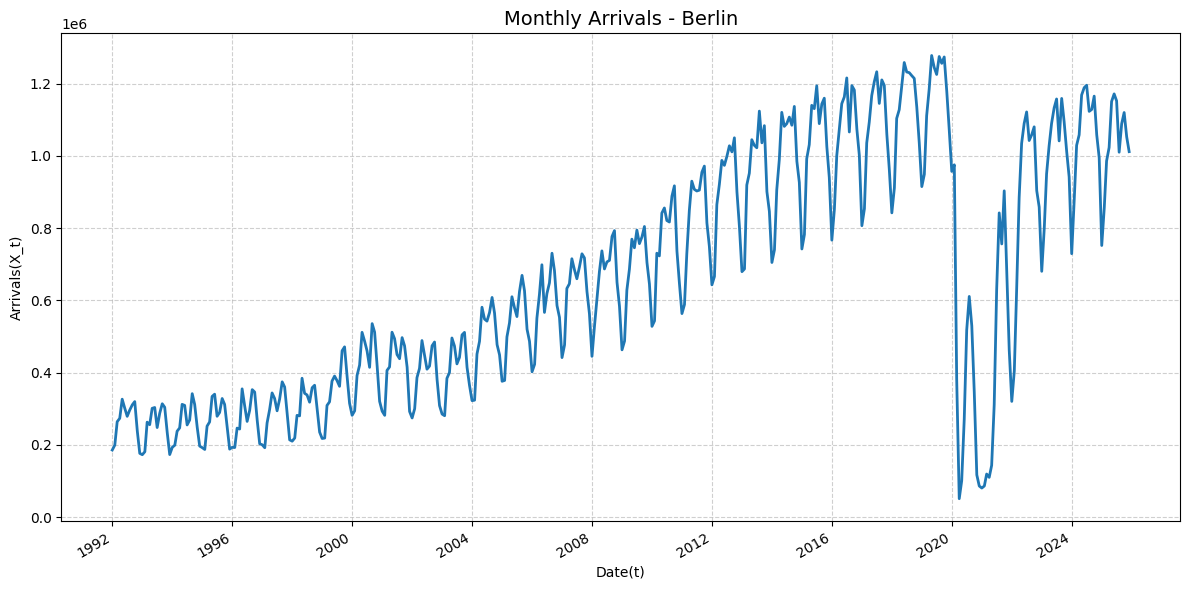

In [482]:
# Time series plot of X_t (enhanced version)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_ts, linewidth=2)

ax.set_title(f"Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel("Arrivals(X_t)")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [483]:
# Test the stationarity of X_t

# Perform KPSS test
kpss_test = KPSS(x_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.000

The time series is not stationary (reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_70478/1503179283.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(x_ts)


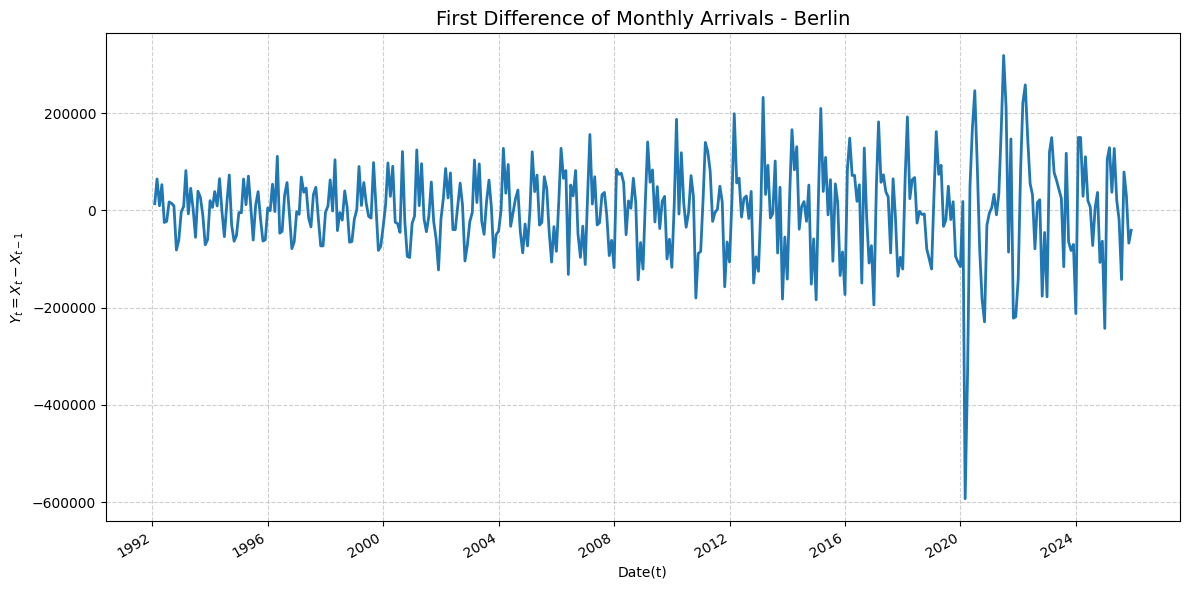

In [484]:
# Time series plot of Y_t := X_t - X_{t-1}

y_ts = x_ts.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_ts, linewidth=2)

ax.set_title(f"First Difference of Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel(r"$Y_t = X_t - X_{t-1}$")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [485]:
# Test the stationarity of Y_t

# Perform KPSS test
kpss_test = KPSS(y_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')


p-value: 0.996

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_70478/1163362364.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(y_ts)


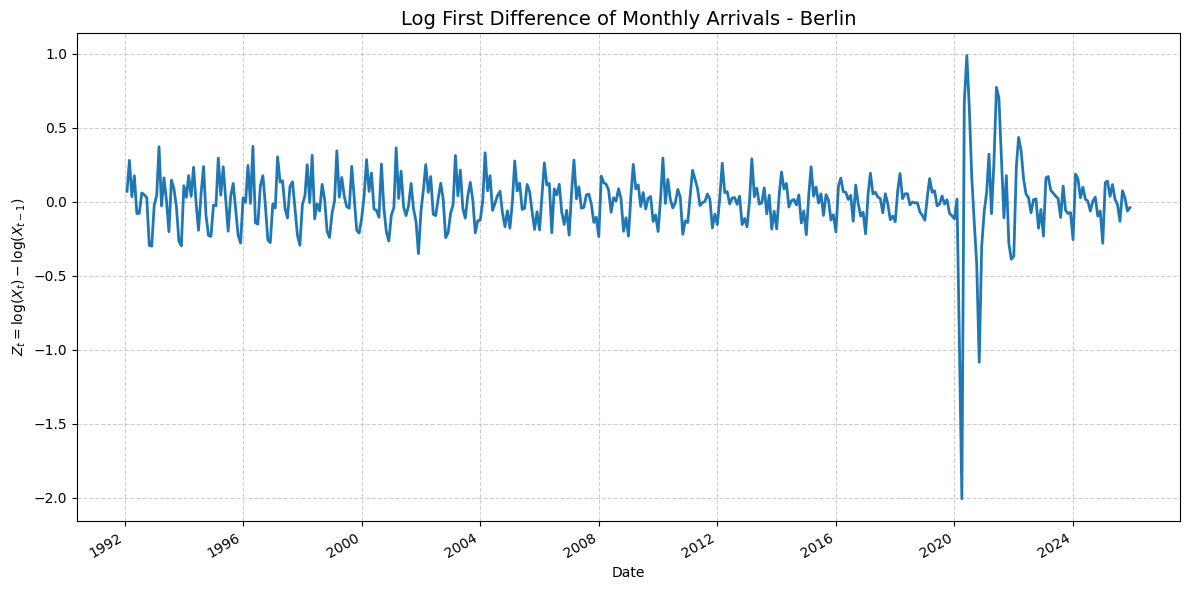

In [486]:
# Time series plot of Z_t := (1 - B) log(X_t)

z_ts = np.log(x_ts).diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(z_ts, linewidth=2)

ax.set_title(f"Log First Difference of Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel(r"$Z_t = \log(X_t) - \log(X_{t-1})$")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [487]:
# Test the stationarity of Z_t

# Perform KPSS test
kpss_test = KPSS(z_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.933

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_70478/3045183312.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(z_ts)


In [488]:
# Split last 12 months as test set

# Training set (log-level)
u1_ts = np.log(x_ts.iloc[:-12])

# Test set (log-level)
u2_ts = np.log(x_ts.iloc[-12:])

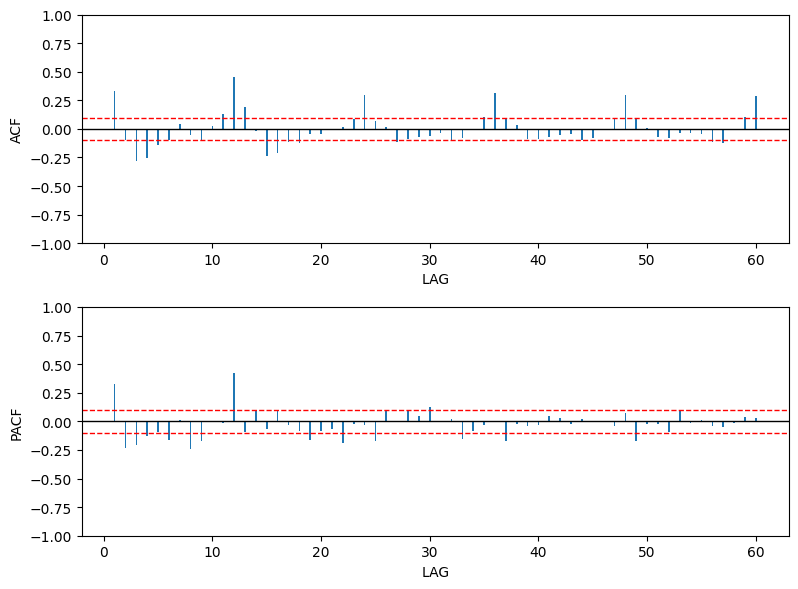

In [489]:
# Plot ACF amd PACF for (1-B)U1_t

fig, axes = plt.subplots(nrows = 2, figsize = (8,6))

acf1(u1_ts.diff().dropna(), nlags = 60, ax = axes[0], width = 0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna(), nlags = 60, ax = axes[1], width = 0.15, pacf = True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

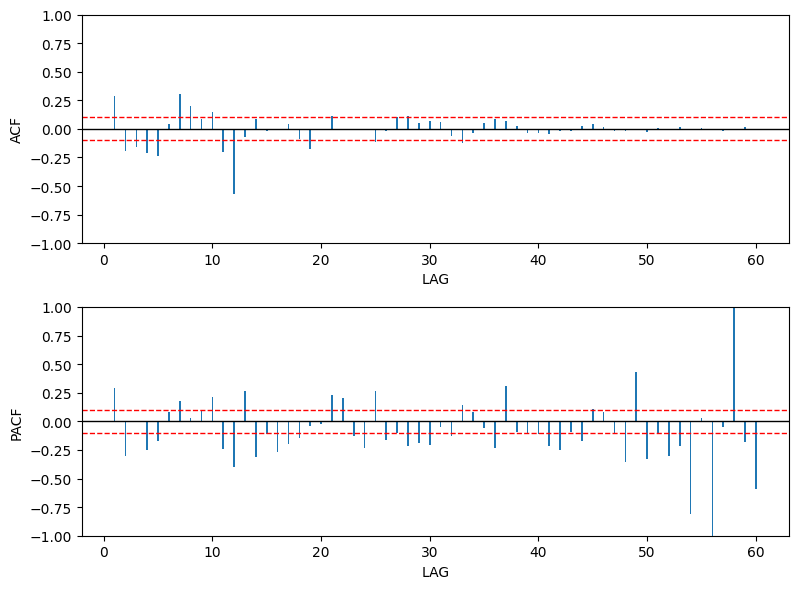

In [490]:
# Plot ACF amd PACF for (1-B^{12})(1-B)U1_t

fig, axes = plt.subplots(nrows = 2, figsize = (8,6))

acf1(u1_ts.diff().dropna().diff(12).dropna().diff(12).dropna(), nlags = 60, ax = axes[0], width = 0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna().diff(12).dropna().diff(12).dropna(), nlags = 60, ax = axes[1], width = 0.15, pacf = True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()


- Initial Suggested Models

1. SARIMA(1,1,0)(0,1,0)_{12}
2. SARIMA(1,1,0)(1,1,0)_{12}
3. SARIMA(1,1,0)(0,1,1)_{12}
4. SARIMA(1,1,0)(1,1,1)_{12}
<br>

5. SARIMA(0,1,1)(0,1,0)_{12}
6. SARIMA(0,1,1)(1,1,0)_{12}
7. SARIMA(0,1,1)(0,1,1)_{12}
8. SARIMA(0,1,1)(1,1,1)_{12}
<br>

9. SARIMA(1,1,1)(0,1,0)_{12}
10. SARIMA(1,1,1)(1,1,0)_{12}
11. SARIMA(1,1,1)(0,1,1)_{12}
12. SARIMA(1,1,1)(1,1,1)_{12}
13. SARIMA(2,1,1)(1,1,1)_{12}

In [ ]:
# Fit a SARIMA(1,1,1)(1,1,1)_{12} model to U1_t

model1 = sm.tsa.arima.ARIMA(u1_ts, order=(1, 1, 2), seasonal_order=(1, 1, 1, 12)).fit(method_kwargs={'maxiter': 500})
print(model1.summary())

#method_kwargs={'maxiter': 500}

                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 163.857
Date:                            Thu, 05 Mar 2026   AIC                           -313.714
Time:                                    09:31:36   BIC                           -286.078
Sample:                                01-01-1992   HQIC                          -302.751
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9150      0.066     13.867      0.000       0.786       1.044
ar.L2         -0.0929      0.073   

In [493]:
model1.mle_retvals['converged']

True

In [456]:
# Fit a SARIMA(4,1,5)(1,1,1)_{12} model to U1_t

model2 = sm.tsa.arima.ARIMA(u1_ts, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
print(model2.summary())

                                    SARIMAX Results                                     
Dep. Variable:                             None   No. Observations:                  396
Model:             ARIMA(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 207.192
Date:                          Wed, 04 Mar 2026   AIC                           -402.384
Time:                                  21:26:12   BIC                           -378.695
Sample:                              01-01-1992   HQIC                          -392.987
                                   - 12-01-2024                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9748      0.048     20.256      0.000       0.880       1.069
ar.L2         -0.4730      0.028    -16.859      0.

In [384]:
model2.mle_retvals['converged']

True

In [427]:
model3 = sm.tsa.arima.ARIMA(u1_ts, order=(2, 1, 2), seasonal_order=(1, 2, 1, 12)).fit(method_kwargs={'maxiter': 500})
print(model3.summary())

/Users/nazilafazeli/Desktop/Capstone/BundesHost/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(2, 1, 2)x(1, 2, [1], 12)   Log Likelihood                 121.935
Date:                            Wed, 04 Mar 2026   AIC                           -229.869
Time:                                    21:16:11   BIC                           -202.456
Sample:                                01-01-1992   HQIC                          -218.982
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5808      0.032     18.246      0.000       0.518       0.643
ar.L2          0.1298      0.046   

In [500]:
# Forecast and confidence boundaries

k = 12 # Number of steps to forecast
u1_ts_preds = model1.get_forecast(steps = k)

# Extract the confidence intervals
conf_int = u1_ts_preds.conf_int()

# Create a DataFrame
forecast_df = pd.DataFrame({
    'predicted_mean': u1_ts_preds.predicted_mean,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})


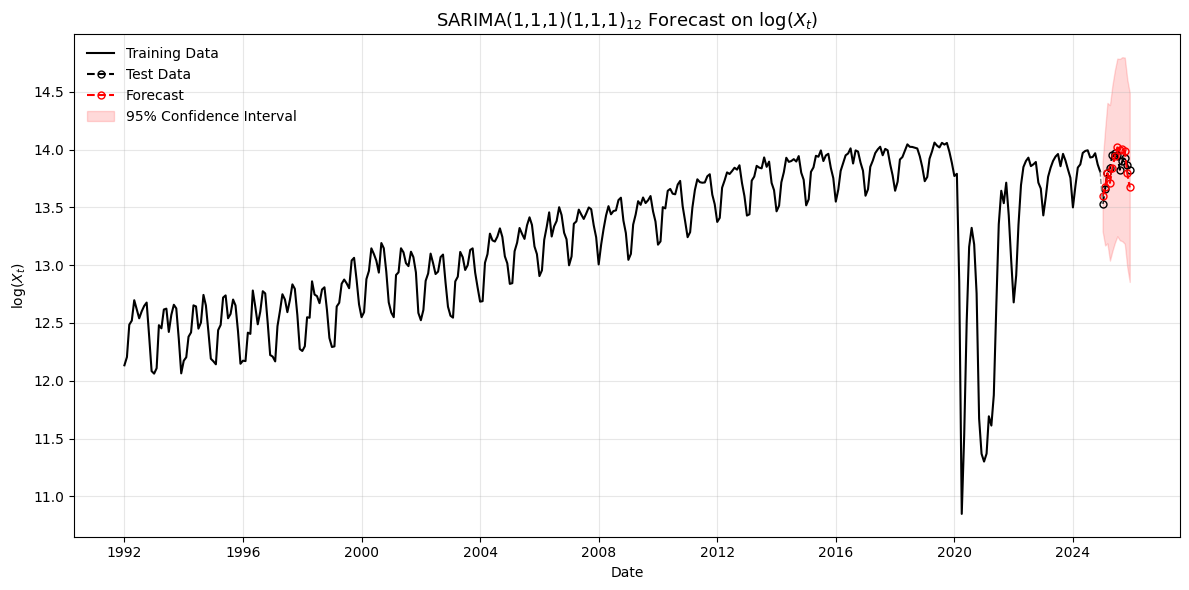

In [501]:
# Plot: Train, Test, Forecast with Confidence Interval

plt.figure(figsize=(12, 6))

# Training data
plt.plot(u1_ts, color='black', linewidth=1.5, label='Training Data')

# Test data
plt.plot(u2_ts, color='black', linestyle='--', marker='o',
         markerfacecolor='none', markersize=5, label='Test Data')

# Forecast
plt.plot(forecast_df['predicted_mean'], color='red',
         linestyle='--', marker='o', markersize=5,
         markerfacecolor='none', label='Forecast')

# Confidence interval
plt.fill_between(
    forecast_df.index,
    forecast_df['lower_ci'],
    forecast_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train point to first test point
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMA(1,1,1)(1,1,1)$_{12}$ Forecast on $\\log(X_t)$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$\\log(X_t)$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

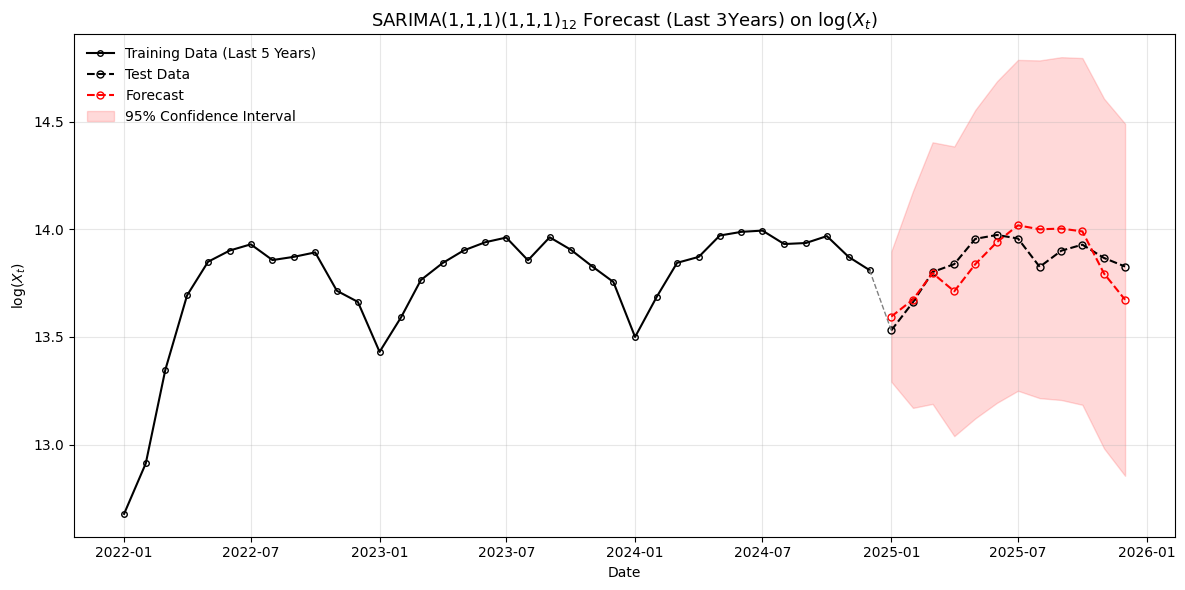

In [502]:
# Plot: Last 3 Years (Zoomed View)

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    u1_ts[-36:],
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts,
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    forecast_df['predicted_mean'],
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df['lower_ci'],
    forecast_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMA(1,1,1)(1,1,1)$_{12}$ Forecast (Last 3Years) on $\\log(X_t)$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$\\log(X_t)$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

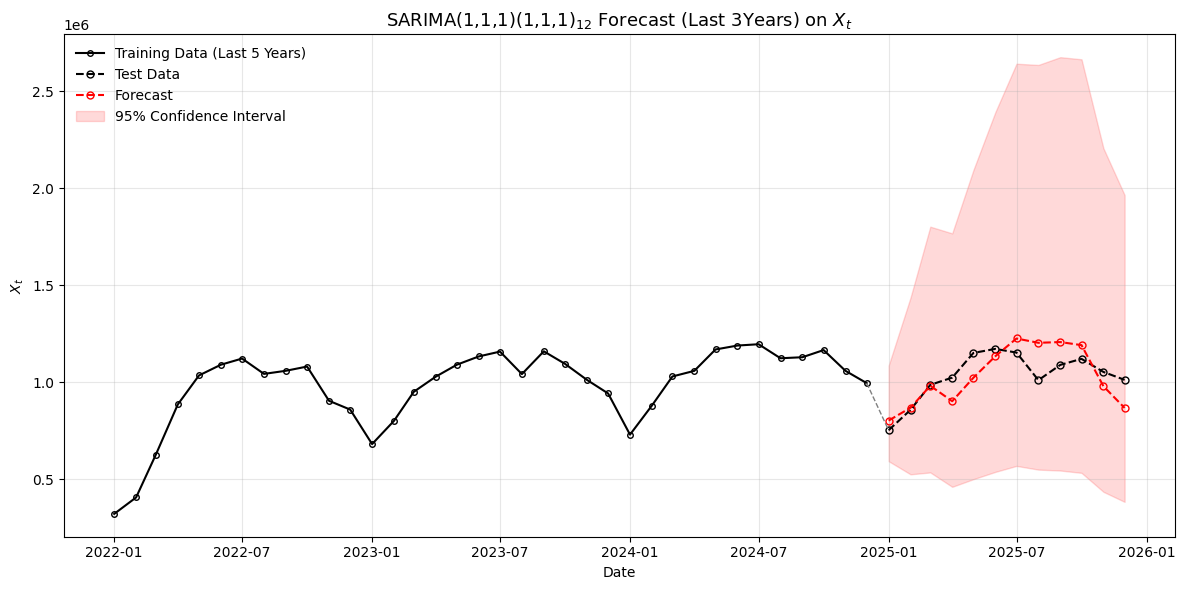

In [503]:
# Plot: Original Scale (X_t) – Last 5 Years

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    np.exp(u1_ts[-36:]),
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts.index,
    np.exp(u2_ts),
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    forecast_df.index,
    np.exp(forecast_df['predicted_mean']),
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    np.exp(forecast_df['lower_ci']),
    np.exp(forecast_df['upper_ci']),
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [np.exp(u1_ts.iloc[-1]), np.exp(u2_ts.iloc[0])],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMA(1,1,1)(1,1,1)$_{12}$ Forecast (Last 3Years) on $X_t$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$X_t$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [504]:
# Calculate the Mean Absolute Percentage Error (MAPE)

errors = np.abs((u2_ts.apply(np.exp) - forecast_df.apply(np.exp)['predicted_mean']) / u2_ts.apply(np.exp))
mape = np.mean(errors) * 100

print(f'The Mean Absolute Percentage Error (MAPE) is: {mape:.2f}%')

The Mean Absolute Percentage Error (MAPE) is: 8.20%


In [505]:
# Convert to original scale
actual = np.exp(u2_ts)
forecast = np.exp(forecast_df['predicted_mean'])

# Align indices
actual, forecast = actual.align(forecast, join='inner')

# MAPE
errors_pct = np.abs((actual - forecast) / actual)
mape = np.mean(errors_pct) * 100

# RMSE
errors = actual - forecast
rmse = np.sqrt(np.mean(errors**2))

print("Forecast Evaluation on Test Set")
print("-" * 40)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f}")
print("-" * 40)

print("\nInterpretation:")
print(f"→ On average, the model's forecasts deviate by approximately {mape:.2f}% from the true values.")
print(f"→ The typical absolute forecasting error is around {rmse:,.0f} arrivals per month.")

Forecast Evaluation on Test Set
----------------------------------------
Mean Absolute Percentage Error (MAPE): 8.20%
Root Mean Squared Error (RMSE): 101,141
----------------------------------------

Interpretation:
→ On average, the model's forecasts deviate by approximately 8.20% from the true values.
→ The typical absolute forecasting error is around 101,141 arrivals per month.


In [506]:
# Create corona dummy for full series

corona_dummy = (
    (x_ts.index >= "2020-03-01") &
    (x_ts.index <= "2021-05-01")
).astype(int)

In [507]:
# Create corona dummy as a pandas Series aligned with x_ts index
corona_dummy = pd.Series(
    ((x_ts.index >= "2020-03-01") &
     (x_ts.index <= "2021-05-01")).astype(int),
    index=x_ts.index,
    name='corona_dummy'
)

# Split exogenous variable into train and test
exog_train = corona_dummy.iloc[:-12]
exog_test  = corona_dummy.iloc[-12:]

In [471]:
print(exog_train.sum())

15


In [509]:
model_exog = sm.tsa.arima.ARIMA( u1_ts, order=(1,1,2), seasonal_order=(1,1,1,12), exog=exog_train).fit(method_kwargs={'maxiter': 500})

print(model_exog.summary())
#method_kwargs={'maxiter': 500}

/Users/nazilafazeli/Desktop/Capstone/BundesHost/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 178.937
Date:                            Wed, 04 Mar 2026   AIC                           -343.873
Time:                                    21:38:21   BIC                           -316.237
Sample:                                01-01-1992   HQIC                          -332.910
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
corona_dummy    -0.9061      0.050    -18.222      0.000      -1.004      -0.809
ar.L1            0.4755      

In [510]:
# Forecast and confidence boundaries with exogenous variable

k = 12  # Number of steps to forecast

u1_ts_preds = model_exog.get_forecast( steps=k, exog=exog_test)

# Extract the confidence intervals
conf_int = u1_ts_preds.conf_int()

# Create a DataFrame
forecast_df = pd.DataFrame({
    'predicted_mean': u1_ts_preds.predicted_mean,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

In [474]:
exog_test.sum()

0

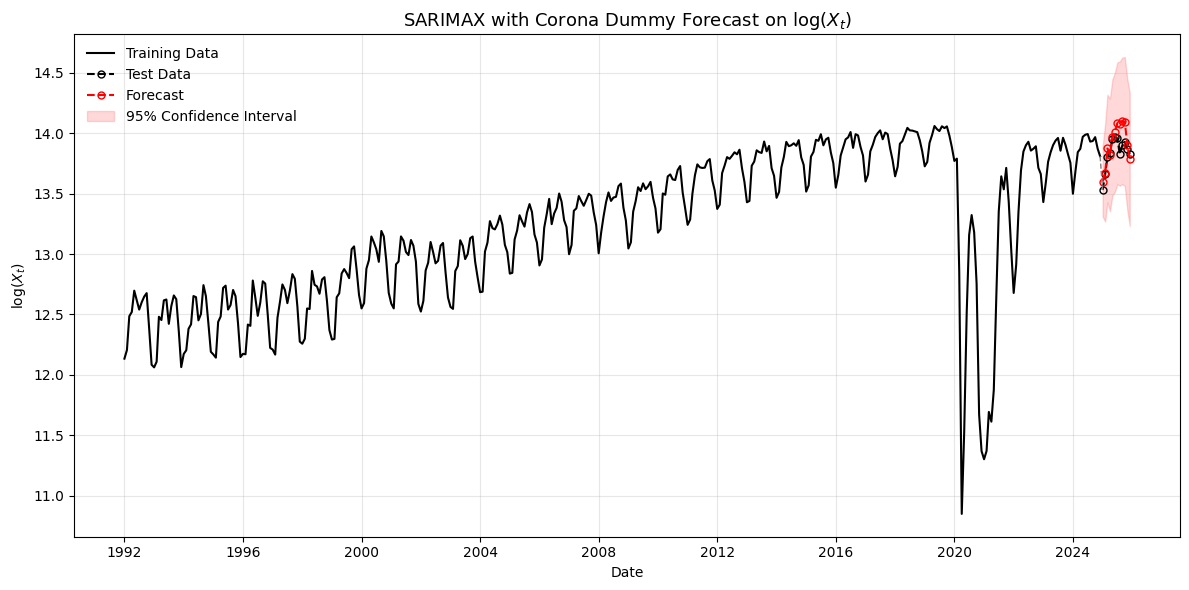

In [511]:
# Plot: Train, Test, Forecast with Confidence Interval

plt.figure(figsize=(12, 6))

# Training data
plt.plot(u1_ts, color='black', linewidth=1.5, label='Training Data')

# Test data
plt.plot(u2_ts, color='black', linestyle='--', marker='o',
         markerfacecolor='none', markersize=5, label='Test Data')

# Forecast
plt.plot(forecast_df['predicted_mean'], color='red',
         linestyle='--', marker='o', markersize=5,
         markerfacecolor='none', label='Forecast')

# Confidence interval
plt.fill_between(
    forecast_df.index,
    forecast_df['lower_ci'],
    forecast_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train point to first test point
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMAX with Corona Dummy Forecast on $\\log(X_t)$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$\\log(X_t)$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

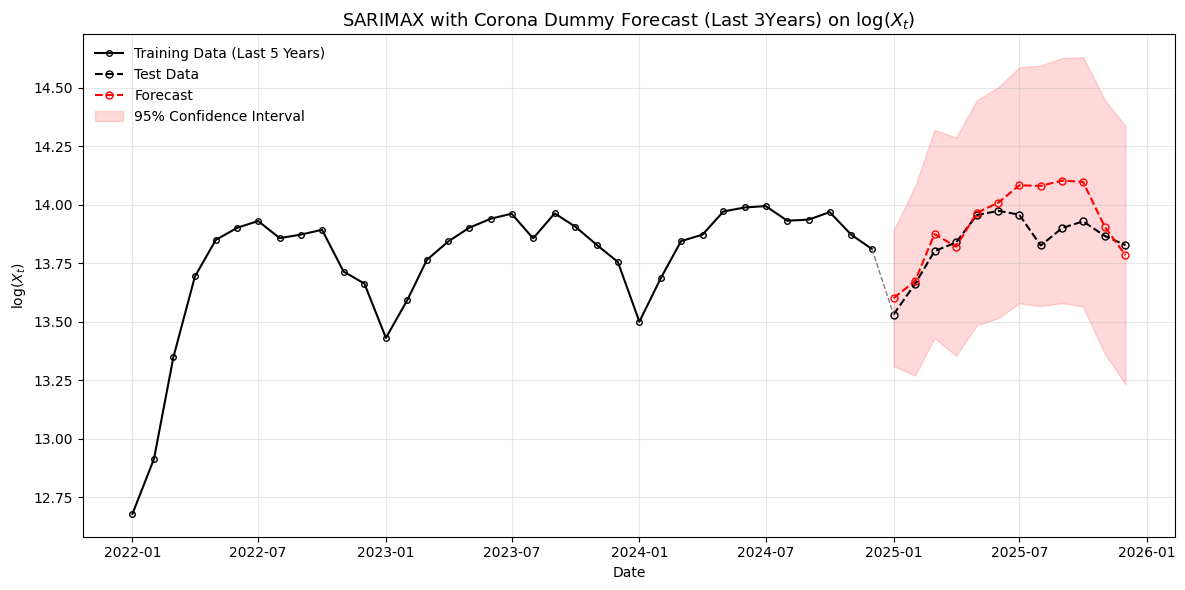

In [512]:
# Plot: Last 3 Years (Zoomed View)

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    u1_ts[-36:],
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts,
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    forecast_df['predicted_mean'],
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df['lower_ci'],
    forecast_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMAX with Corona Dummy Forecast (Last 3Years) on $\\log(X_t)$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$\\log(X_t)$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

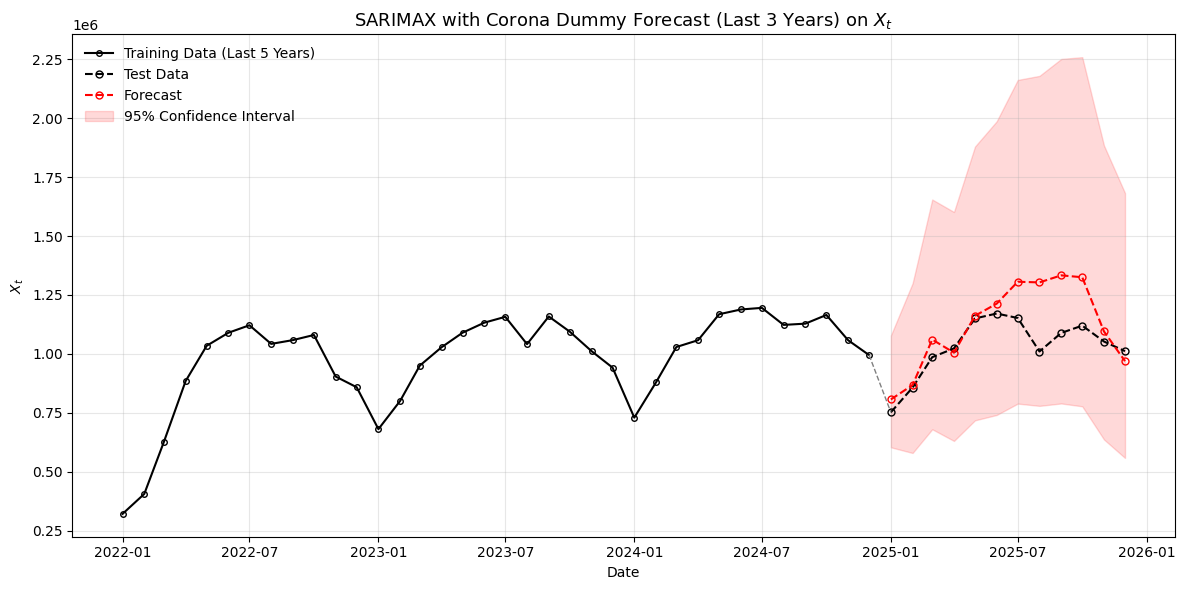

In [513]:
# Plot: Original Scale (X_t) – Last 5 Years

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    np.exp(u1_ts[-36:]),
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts.index,
    np.exp(u2_ts),
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    forecast_df.index,
    np.exp(forecast_df['predicted_mean']),
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    np.exp(forecast_df['lower_ci']),
    np.exp(forecast_df['upper_ci']),
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [np.exp(u1_ts.iloc[-1]), np.exp(u2_ts.iloc[0])],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMAX with Corona Dummy Forecast (Last 3 Years) on $X_t$', fontsize=13)
plt.xlabel('Date')
plt.ylabel('$X_t$')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [514]:
# Convert to original scale
actual = np.exp(u2_ts)
forecast = np.exp(forecast_df['predicted_mean'])

# Align indices
actual, forecast = actual.align(forecast, join='inner')

# MAPE
errors_pct = np.abs((actual - forecast) / actual)
mape = np.mean(errors_pct) * 100

# RMSE
errors = actual - forecast
rmse = np.sqrt(np.mean(errors**2))

print("Forecast Evaluation on Test Set")
print("-" * 40)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f}")
print("-" * 40)

print("\nInterpretation:")
print(f"→ On average, the model's forecasts deviate by approximately {mape:.2f}% from the true values.")
print(f"→ The typical absolute forecasting error is around {rmse:,.0f} arrivals per month.")

Forecast Evaluation on Test Set
----------------------------------------
Mean Absolute Percentage Error (MAPE): 9.49%
Root Mean Squared Error (RMSE): 137,352
----------------------------------------

Interpretation:
→ On average, the model's forecasts deviate by approximately 9.49% from the true values.
→ The typical absolute forecasting error is around 137,352 arrivals per month.


## Structural State Space

In [516]:
# Select Berlin data
df_berlin = X[X['state'] == 'Berlin'].copy()

# Create time series
x_ts = pd.Series(
    df_berlin['arrivals'].values,
    index=pd.to_datetime(df_berlin['date'])
).asfreq('MS')

# Log transform (same as before)
u_ts = np.log(x_ts)

u_ts.head()

date
1992-01-01    12.133642
1992-02-01    12.204772
1992-03-01    12.485196
1992-04-01    12.520299
1992-05-01    12.696908
Freq: MS, dtype: float64

In [518]:
# Train-test split (same as before)
u_train = u_ts.iloc[:-12]
u_test  = u_ts.iloc[-12:]

u_train.tail(), u_test.head()

(date
 2024-08-01    13.931531
 2024-09-01    13.936274
 2024-10-01    13.968424
 2024-11-01    13.871983
 2024-12-01    13.810258
 Freq: MS, dtype: float64,
 date
 2025-01-01    13.530464
 2025-02-01    13.661247
 2025-03-01    13.801373
 2025-04-01    13.838426
 2025-05-01    13.955640
 Freq: MS, dtype: float64)

In [519]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Define structural time series model
model_ss = UnobservedComponents(
    u_train,
    level='local linear trend',
    seasonal=12
)

# Fit the model
result_ss = model_ss.fit()

print(result_ss.summary())

                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  396
Model:                    local linear trend   Log Likelihood                 108.598
                   + stochastic seasonal(12)   AIC                           -209.196
Date:                       Wed, 04 Mar 2026   BIC                           -193.403
Time:                               21:57:03   HQIC                          -202.931
Sample:                           01-01-1992                                         
                                - 12-01-2024                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  5.269e-11      0.001   6.81e-08      1

In [521]:
# Convert forecast to original scale
forecast_ss_mean = np.exp(forecast_mean)

actual = np.exp(u_test)

# Align indices
actual, forecast_ss_mean = actual.align(forecast_ss_mean, join='inner')

# MAPE
mape_ss = np.mean(np.abs((actual - forecast_ss_mean) / actual)) * 100

# RMSE
rmse_ss = np.sqrt(np.mean((actual - forecast_ss_mean) ** 2))

print("Structural State Space Model Evaluation")
print("-" * 45)
print(f"MAPE: {mape_ss:.2f}%")
print(f"RMSE: {rmse_ss:,.0f}")
print("-" * 45)

Structural State Space Model Evaluation
---------------------------------------------
MAPE: 17.07%
RMSE: 217,439
---------------------------------------------


In [522]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

model_ss2 = UnobservedComponents(
    u_train,
    level='local linear trend',
    seasonal=12,
    autoregressive=1   # add AR(1) disturbance
)

result_ss2 = model_ss2.fit()

print(result_ss2.summary())

                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  396
Model:                    local linear trend   Log Likelihood                 113.245
                   + stochastic seasonal(12)   AIC                           -214.491
                                     + AR(1)   BIC                           -190.803
Date:                       Wed, 04 Mar 2026   HQIC                          -205.094
Time:                               22:02:17                                         
Sample:                           01-01-1992                                         
                                - 12-01-2024                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [523]:
# Forecast 12 months ahead
forecast_ss2 = result_ss2.get_forecast(steps=12)

forecast_mean2 = forecast_ss2.predicted_mean

# Convert to original scale
forecast_ss2_mean = np.exp(forecast_mean2)
actual = np.exp(u_test)

# Align indices
actual, forecast_ss2_mean = actual.align(forecast_ss2_mean, join='inner')

# MAPE
mape_ss2 = np.mean(np.abs((actual - forecast_ss2_mean) / actual)) * 100

# RMSE
rmse_ss2 = np.sqrt(np.mean((actual - forecast_ss2_mean) ** 2))

print("Structural State Space + AR(1) Evaluation")
print("-" * 45)
print(f"MAPE: {mape_ss2:.2f}%")
print(f"RMSE: {rmse_ss2:,.0f}")
print("-" * 45)

Structural State Space + AR(1) Evaluation
---------------------------------------------
MAPE: 9.19%
RMSE: 119,985
---------------------------------------------


In [524]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Structural model with AR(2) disturbance
model_ss3 = UnobservedComponents(
    u_train,
    level='local linear trend',
    seasonal=12,
    autoregressive=2   # AR(2) instead of AR(1)
)

result_ss3 = model_ss3.fit()

print(result_ss3.summary())

                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  396
Model:                    local linear trend   Log Likelihood                 153.983
                   + stochastic seasonal(12)   AIC                           -293.965
                                     + AR(2)   BIC                           -266.329
Date:                       Wed, 04 Mar 2026   HQIC                          -283.003
Time:                               22:05:20                                         
Sample:                           01-01-1992                                         
                                - 12-01-2024                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [525]:
# Forecast 12 months ahead
forecast_ss3 = result_ss3.get_forecast(steps=12)
forecast_mean3 = forecast_ss3.predicted_mean

# Convert to original scale
forecast_ss3_mean = np.exp(forecast_mean3)
actual = np.exp(u_test)

# Align indices
actual, forecast_ss3_mean = actual.align(forecast_ss3_mean, join='inner')

# MAPE
mape_ss3 = np.mean(np.abs((actual - forecast_ss3_mean) / actual)) * 100

# RMSE
rmse_ss3 = np.sqrt(np.mean((actual - forecast_ss3_mean) ** 2))

print("Structural State Space + AR(2) Evaluation")
print("-" * 45)
print(f"MAPE: {mape_ss3:.2f}%")
print(f"RMSE: {rmse_ss3:,.0f}")
print("-" * 45)

Structural State Space + AR(2) Evaluation
---------------------------------------------
MAPE: 9.87%
RMSE: 143,639
---------------------------------------------


In [526]:
# Create corona dummy aligned with full series
corona_dummy = (
    (u_ts.index >= "2020-03-01") &
    (u_ts.index <= "2021-06-01")
).astype(int)

# Convert to pandas Series with same index
corona_dummy = pd.Series(corona_dummy, index=u_ts.index)

# Split dummy into train and test
exog_train = corona_dummy.iloc[:-12]
exog_test  = corona_dummy.iloc[-12:]

exog_train.sum(), exog_test.sum()

(16, 0)

In [534]:
model_ss4 = UnobservedComponents(
    u_train,
    level='local linear trend',
    seasonal=12,
    autoregressive=1,
    exog=exog_train   # add corona dummy
)

result_ss4 = model_ss4.fit(maxiter=2000, disp=False)

print(result_ss4.summary())

                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  396
Model:                    local linear trend   Log Likelihood                 165.067
                   + stochastic seasonal(12)   AIC                           -316.134
                                     + AR(1)   BIC                           -288.498
Date:                       Wed, 04 Mar 2026   HQIC                          -305.172
Time:                               22:10:23                                         
Sample:                           01-01-1992                                         
                                - 12-01-2024                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [535]:
result_ss4.mle_retvals['converged']

True

In [537]:
# Forecast 12 months ahead
forecast_ss4 = result_ss4.get_forecast(steps=12, exog=exog_test)

forecast_mean4 = forecast_ss4.predicted_mean

# Convert to original scale
forecast_ss4_mean = np.exp(forecast_mean4)
actual = np.exp(u_test)

# Align indices
actual, forecast_ss4_mean = actual.align(forecast_ss4_mean, join='inner')

# MAPE
mape_ss4 = np.mean(np.abs((actual - forecast_ss4_mean) / actual)) * 100

# RMSE
rmse_ss4 = np.sqrt(np.mean((actual - forecast_ss4_mean) ** 2))

print("Structural + AR(1) + Dummy Evaluation")
print("-" * 45)
print(f"MAPE: {mape_ss4:.2f}%")
print(f"RMSE: {rmse_ss4:,.0f}")
print("-" * 45)

Structural + AR(1) + Dummy Evaluation
---------------------------------------------
MAPE: 9.26%
RMSE: 128,949
---------------------------------------------
